# ¡Hola Jose!

Mi nombre es Sofia Arboleda, estaré ayudándote a revisar este proyecto para que quede en su mejor versión.

Para simular la dinámica de un ambiente de trabajo, si veo algún error, en primer instancia solo los señalaré, dándote la oportunidad de encontrarlos y corregirlos por tu cuenta. Esto es útil para que te acostumbres a un escenario laboral. En caso de que no puedas resolver la tarea, te daré una información más precisa en la próxima revisión.

Encontrarás mis comentarios más abajo - **por favor, no los muevas, no los modifiques ni los borres**.

¿Cómo funciona esta revisión? Leeré atentamente tu código y te señalaré tus fortalezas y aquellas cosas que podemos mejorar. Los comentarios aparecerán de esta forma:


<div class="alert alert-block alert-success">
<b>Comentario de la revisora</b> <a class="tocSkip"></a>

Si todo está perfecto y no se requieren cambios en el código.
</div>


<div class="alert alert-block alert-warning">
<b>Comentario de la revisora</b> <a class="tocSkip"></a>

Si tu código está bien pero se puede mejorar o hay algún detalle que le hace falta. Se aceptan uno o dos comentarios de este tipo en el borrador, pero si hay más, deberás hacer las correcciones.
</div>

<div class="alert alert-block alert-danger">

<b>Comentario de la revisora</b> <a class="tocSkip"></a>

Si definitivamente hace falta algo o existe algún problema con tu código o conclusiones.
</div>

Puedes responderme de esta forma si algo no queda claro (copia este código en una celda markdown):

<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class="tocSkip"></a>

Hola, muchas gracias por tus comentarios y la revisión.        
</div>

# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respalda tus conclusiones mediante gráficos claros.

Se aplican **puebas estadísticas apropiados** para comparar las páginas y **recomendar qué versión es mejor**, justificando la decisión con datos.

### Comentario General Iteración #1
<div class="alert alert-block alert-success">

Jose, quería dejarte aquí una apreciación general de tu proyecto para que a partir de allí nos vayamos punto por punto. 

Primero que nada, espero qu este camino en el mundo de los datos esté siendo muy interesante y lleno de aprendizajes significativos. Espero que lo disfrutes y puedas hacerte muchas preguntas que te lleven a analizar y ver los datos como si fueran historias, porque al final, ese es nuestro objetivo!

Respecto a tu trabajo en esta primera iteración, felicitarte porque has mostrado tus conocimientos de la mejor forma, utilizando los metodos correctamente, realizando filtros de forma sencilla y trabajando con los diferentes datasets y las pruebas de hipotesis para llegar a las respuestas de negocio que se buscaban en este proyecto. 

Sigue aprendiendo bastante en este camino, excelente trabajo!
</div>

## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [1]:
# importar librerías
import pandas as pd
from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
# cargar archivo
df = pd.read_csv('/datasets/landing_experiment.csv')

**Vista previa e información general del conjunto de datos**

In [3]:
# mostrar las primeras 5 filas
df.head(5)

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [4]:
# información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB


- No se identificaron valores nulos en las principales variables, por lo que no se requiere hacer imputaciones o eliminaciones de datos en esta etapa.
- Por ejemplo, las variables landing, traffic_source y user_type están en sus formatos adecuados (objeto), mientras que converted está en formato numérico (1,0), lo cual es lo adecuado para su análisis.
- La variable de gasto es numérico, lo cual es adecuado para analizar futuras estadisticas.
- siendo como conclusión final: el dataset esta limpio y apto para el analisis y las pruebas estadisticas.

**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id` — Identificador único del usuario
- `date` — Fecha en la que el usuario fue expuesto a la página
- `landing` — Versión de la página mostrada al usuario
- `region` — Región geográfica del usuario
- `dispositivo` — Tipo de dispositivo utilizado por el usuario
- `traffic_source` — Canal por el que llegó el usuario
- `user_type` — Tipo de usuario según historial previo
- `converted` — Indica si el usuario realizó una conversión
- `gasto` — Monto gastado por el usuario (0 si no convirtió)

### 1.2 Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.



 **Variable `user_id`**  
 Verificar usuarios únicos


In [5]:
usuarios_unicos = df['user_id'].nunique()

 **Variable `date`**  
Explorar rango de fechas

In [6]:
# Resumen estadístico
df["date"].describe()

count          40000
unique            28
top       2026-01-24
freq            1512
Name: date, dtype: object

In [7]:
# Identificar rango temporal del experimento
print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())

Fecha mínima: 2026-01-01
Fecha máxima: 2026-01-28


**Variable `gasto` (numérica)**

In [8]:
# Resumen estadístico
resumen_gasto = df['gasto'].describe()

In [9]:
# Resumen estadístico de usuarios que se convirtieron
resumen_convertidos = df['gasto'].describe()
resumen_convertidos

count    40000.000000
mean         9.325554
std         25.667986
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        303.680000
Name: gasto, dtype: float64

 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).

In [10]:
# Explorar variables categóricas y cómo se distribuyen
print("\nConteo de categorías:")


Conteo de categorías:


In [11]:
print(df['landing'].value_counts())

B    20018
A    19982
Name: landing, dtype: int64


- Todas las columnas tienen valores esperados.

<div class="alert alert-block alert-success">
<b>Comentario del revisor Iteración 1.</b>

Muy buen trabajo con los métodos de analisis exploratorio para entender las caracteristicas de los datos, sus estadisticas y los rangos del experimento. 

## 💰 Paso 2: Comparar el gasto promedio por usuario (página A vs B)

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [12]:
# Gasto por versión
gasto_A = df[(df['landing'] == 'A') & (df['converted'] == 1)]['gasto'] #completa el código
gasto_B = df[(df['landing'] == 'B') & (df['converted'] == 1)]['gasto'] #completa el código

In [13]:
# Verificar cantidad de datos que tiene cada grupo
len(gasto_A), len(gasto_B)

(2512, 3194)

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** No hay diferencia en el gasto promedio entre los usuarios de la página A y la página B.
- **Hipótesis alternativa (H₁):** Sí hay diferencia en el gasto promedio entre los usuarios de la página A y la página B.

In [14]:
# Aplicar prueba
t_stat, p_value = ttest_ind(gasto_A, gasto_B, equal_var=False)

In [15]:
# Visualizar resultados
print(f"Estadístico :  {t_stat}")
print(f"Valor p: {p_value}")

Estadístico :  -9.48101092267275
Valor p: 3.627602231521493e-21


In [16]:
gasto_A.mean(), gasto_B.mean()

(61.0865724522293, 68.74536005009392)

### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipótesis nula (H₀).

**Interpretación de negocio:**  
Se encontraron diferencias significativas en el gasto promedio; se puede tomar una decisión basada en datos para optimizar su estrategia. La versión B es la que debería ser implementada, ya que no solo convierte usuarios, sino que genera más valor económico.


<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración 1.</b>

Buen trabajo con la elección de la prueba `ttest` en este caso y la interpretación del resultado del valor p frente a tu hipotesis nula. 

---


## 📈 Paso 3: Comparar la tasa de conversión entre la página A y B

Se evalua si existen difere]ncias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** La tasa de conversión es igual entre la página A y la página B.
- **Hipótesis alternativa (H₁):** La tasa de conversión es diferente entre la página A y la página B.

In [17]:
# Número de usuarios convertidos por página
convertidos = df.groupby('landing')['converted'].sum()

# Total de usuarios por página
total_usuarios = df.groupby('landing')['converted'].count()

In [18]:
print("Usuarios convertidos por página:\n", convertidos)
print("\nTotal de usuarios por página:\n", total_usuarios)

Usuarios convertidos por página:
 landing
A    2512
B    3194
Name: converted, dtype: int64

Total de usuarios por página:
 landing
A    19982
B    20018
Name: converted, dtype: int64


In [19]:
# Aplicar prueba
t_stat, p_value = ttest_ind(convertidos, total_usuarios, equal_var=False)

# Visualizar resultados
print(f"Estadístico :  {t_stat}")
print(f"Valor p: {p_value}")

Estadístico :  -50.214548394465325
Valor p: 0.012416132047021836


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipótesis nula (H₀).

**Interpretación de negocio:**  
La página B tiene mayor tasa de conversión en comparación con la página A, siendo una diferencia significativa, lo que indica que nos es algo improvisado o al azar.

<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración 1.</b>

Excelente elección del`ttest`. Tu interpretación es correcta, el resultado indica que la tasa de conversión de la página A es menor que la de la página B, por lo que podemos concluir que la página B convierte a más usuarios que la página A.


## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** No existe relación entre la fuente de tráfico (traffic_source) y la conversión (conversion).
- **Hipótesis alternativa (H₁):** Sí existe una relación entre la fuente de tráfico (traffic_source) y la conversión (conversion).

In [20]:
tabla = pd.crosstab(df['traffic_source'], df['converted'])

In [21]:
# Aplicar prueba
chi2, p_value, dof, expected = chi2_contingency(tabla)

In [22]:
print("Tabla de contingencia:\n", tabla)
print(f"\nEstadístico Chi-cuadrado: {chi2}")
print(f"Valor p: {p_value}")
print(f"Grados de libertad: {dof}")

Tabla de contingencia:
 converted           0     1
traffic_source             
Ads             10176  1759
Email            5205   918
Organic         15507  2480
Referral         3406   549

Estadístico Chi-cuadrado: 8.662108841397938
Valor p: 0.0341375947833914
Grados de libertad: 3


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipótesis nula (H₀).

**Interpretación de negocio:**  
Se establece que hay una relación significativa entre la fuente de tráfico y la conversión, significando que el canal que refiere a los usuarios influye en la probabilidad de convertirse. Recomendando mantener estrategias en organic para asegurar su volumen, así como optimizar en email y ads, ya que son los que presentan mayor eficiencia en conversión y pueden llegar a tener mayor retorno.

<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración 1.</b>

Buen trabajo con el test de `chi2` de nuevo. La interpretación que proporcionas es muy acertada, la probabilidad de conversión depende del canal de tráfico, por lo que la estrategia óptima debería considerar tanto impacto total como eficiencia de conversión.

## 👤 Paso 5: Revisar la relación entre el tipo de usuario y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** No existe relación entre el tipo de usuario (user_type) y la conversión (converted).
- **Hipótesis alternativa (H₁):** Sí existe relación entre el tipo de usuario (user_type) y la conversión (converted).

In [23]:
tabla = pd.crosstab(df['user_type'], df['converted'])

In [24]:
# Aplicar prueba
chi2, p_value, dof, expected = chi2_contingency(tabla)


In [25]:
print("Tabla de contingencia:\n", tabla)
print(f"\nEstadístico Chi-cuadrado: {chi2}")
print(f"Valor p: {p_value}")
print(f"Grados de libertad: {dof}")

Tabla de contingencia:
 converted       0     1
user_type              
Nuevo       22295  3738
Recurrente  11999  1968

Estadístico Chi-cuadrado: 0.5134849494478645
Valor p: 0.4736341272301974
Grados de libertad: 1


### 📝 Conclusión e interpretación

**Decisión:**  
No se rechaza la hipótesis nula (H₀).

**Interpretación de negocio:**  
Indican que no hay una relación estadísticamente significativa entre el tipo de usuario y la conversión. Significando que un usuario nuevo o recurrente no influya significativamente en su probabilidad de convertirse. Se pueden enfocar las decisiones en otros factores más relevantes, como la fuente de tráfico o la versión de la página.

<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración 1.</b>

Bien hecho! No hay evidencia estadísticamente significativa de que el tipo de usuario afecte la conversión. Esto podría indicae que los perfiles de usuario convierten de manera similar, y no es necesario priorizar un tipo de usuario específico para mejorar la tasa de conversión.

## 📊 Paso 6: Visualizar los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.

### Relación entre la fuente de tráfico y la conversión

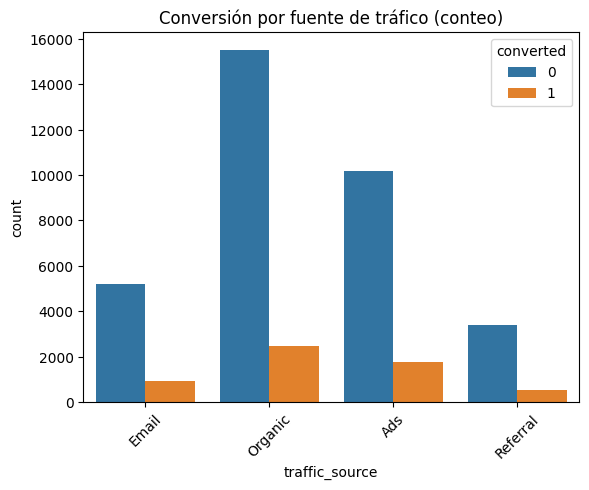

In [26]:
sns.countplot(data=df, x='traffic_source', hue='converted')
plt.title('Conversión por fuente de tráfico (conteo)')
plt.xticks(rotation=45)
plt.show()

- Se puede observar la cantidad de usuarios que se convirtieron (1) y los que no convirtieron (0) de cada fuente de tráfico.

- Se puede observar que Organic es la fuente de mayor volumen de usuarios, tanto en conversiones como en no conversiones, seguidas por Ads, Email y Referral.

- En cuestión de volumen: Organic, Ads son los que mayor cantidad de conversiones tienen, siendo los principales canales de adquisición, pero a su vez presentan una cantidad alta de usuarios que no convierten, siendo un área de oportunidad.

### Relación entre el tipo de usuario y la conversión

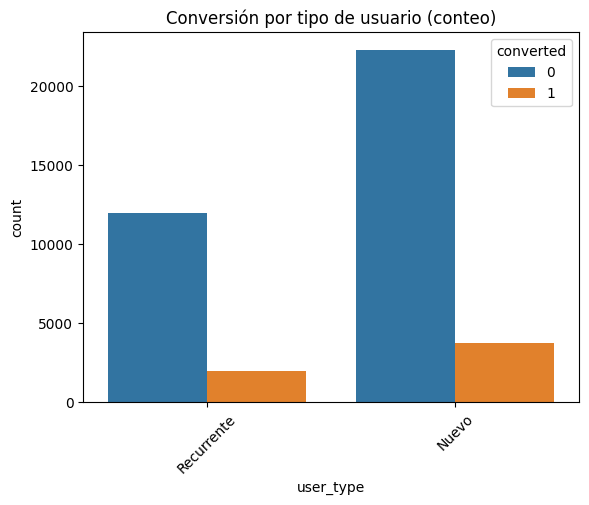

In [27]:
sns.countplot(data=df, x='user_type', hue='converted')
plt.title('Conversión por tipo de usuario (conteo)')
plt.xticks(rotation=45)
plt.show()

- Se observa que los usuarios nuevos representan el mayor volumen total, tanto en conversiones como en no conversiones, mientras que los recurrentes tienen menos participación.
- Al observar la proporción entre usuarios que convierten y los que no en ambos grupos, se aprecia que el comportamiento es muy similar, sugiriendo que no hay diferencia clara en la tasa de conversión entre usuarios nuevos y recurrentes.

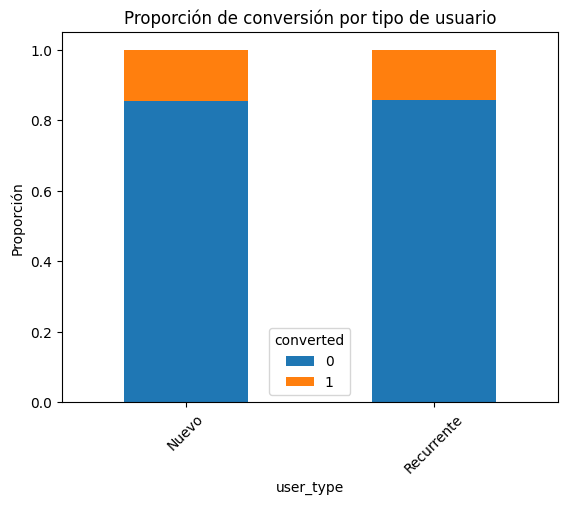

In [28]:
tabla_prop = pd.crosstab(df['user_type'], df['converted'], normalize='index')

tabla_prop.plot(kind='bar', stacked=True)
plt.title('Proporción de conversión por tipo de usuario')
plt.ylabel('Proporción')
plt.xticks(rotation=45)
plt.show()

- Se puede observar que ambas categorías presentan proporciones similares, teniendo el 85% de usuarios que no convierten contra el 15% de los que si convierten en cada grupo.
- En términos de relación, no se presenta una diferencia significativa en la tasa de conversión entre los usuarios nuevos y recurrentes, ya que ambos presentan un comportamiento similar.

<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración 1.</b>

Bien hecho aquí con las comparaciones entre usuarios que convierten y no convierten y sus tipos. Como mencionas, se aprecia que las tasas de conversión son similares entre usuarios nuevos y recurrentes.

## 🧩 Paso 7. Insight Ejecutivo para Stakeholders

Se traducen los hallazgos del análisis del experimento A/B en conclusiones accionables para el negocio, enfocadas en **versión de página, conversión, gasto promedio, canales de tráfico y tipo de usuario**.

**Preguntas a responder:**  
- ¿Qué página genera mayor conversión y gasto promedio?
- La página B tiene mejor desempeño general.
- Muestra una mayor tasa de conversión y, por otro lado, genera un mayor gasto promedio por usuario.
  
- ¿Qué canales de tráfico son más efectivos para generar conversiones?
- Organic y Ads son los que más volumen de conversión generan; son las principales fuentes de adquisición.
- En cambio, Email y Ads presentan mayor eficiencia de conversión dada la tasa ligeramente alta.
  
- ¿Existen diferencias significativas según el tipo de usuario?
- No se observan diferencias estadísticamente significativas entre los usuarios nuevos y recurrentes en cuanto al tema de conversión.
- Ambos grupos presentan una tasa de conversión similar, por lo que no es determinante el tipo de usuario.
  
- ¿Qué recomendaciones se pueden tomar para optimizar la estrategia de marketing?
- Implementación en la página B como la versión principal (maximiza la conversión como el ingreso de usuario).
- Mantener y optimizar el canal Organic, ya que asegura el volumen de tráfico.
- Canales como Ads y Email no deben ser ignorados, ya que presentan buenas tasas de conversión.
- No generar segmentos estratégicos por tipo de usuario, ya que no presentan diferencias relevantes en la conversión.
- Reforzar la optimización de embudo y experiencia, más que en el tipo de usuario.

### 🌟 Insight Ejecutivo basado en el Experimento A/B

#### 🔍 **Comparación de página (A vs B)**  

**Gasto promedio por usuario que convirtió:**
- Observacion 1: La página B presenta un mayor gasto promedio de (68.75) en comparación con la página A (61.09).
  
- Observación 2: La diferencia en el gasto promedio es significativa estadísticamente (p < 0.05), indicando que no es producto al azar.

- **Interpretación:**
La página B tiene mayor valor económico por usuario, siendo más rentable para el negocio.

**Tasa de conversión:** 
- Observación 1: La página B tiene mayor tasa de conversión (~15.95%) en comparación con la página A (~12.57%).
- Observación 2: La diferencia entre las tasas de conversión estadísticamente es significativa (p < 0.05).
  
- **Interpretación:**
La página B es más efectiva para la conversión de usuarios a clientes, lo que genera un impacto directo en el crecimiento del negocio.

#### 📊 **Segmentación por fuente de tráfico**
- Observación: Los canales Organic y Ads generan mayor volumen de conversiones, mientras que Email y Ads presentan tasas de conversión ligeramente más altas.
  
- **Interpretación:**
Organic es una pieza clave para el volumen, mientras que Ads y Email muestran eficiencia, lo que da a entender que existen oportunidades de optimización en la inversión por canal.

#### 📊 **Segmentación por tipo de usuario**
- Observación: Los usuarios nuevos generan más conversiones en términos absolutos, pero la tasa de conversión entre usuarios nuevos y recurrentes es similar.
  
- **Interpretación:**
El tipo de usuario no influye de manera significativa en la conversión, por lo que no es un factor clave para segmentar estrategias.

#### 💡 **Recomendaciones de negocio:** 
- Implementar la página B como la versión principal para maximizar conversiones y revenue.
- Mantener el canal Organic para asegurar el volumen de tráfico.
- Generar un incremento en Ads y Email, debido a que muestran una mayor eficiencia en la conversión.
- Centrarse en las estrategias de optimización de la experiencia y el embudo, más que en la segmentación por tipo de usuario.

<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración 1.</b>

Excelentes conclusiones y propuestas finales de negocio frente a los resultados, has recopilado cada uno de los hallazgos convirtiendolos en acciones clave, esto es justamente lo que se espera en este nivel de analisis. Sigue así!